# Silver Layer EDA - 10 Step PySpark EDA Analyzer

In [2]:

import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.types import *

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.config.engine_session import get_spark_session

spark = get_spark_session("SilverLayerEDA")

print("Membaca Tabel Silver...")
df_eng = spark.read.parquet("s3a://silver/fact_england_water_quality")
df_wims = spark.read.parquet("s3a://silver/fact_wims_water_quality")
df_dim = spark.read.parquet("s3a://silver/dim_station_population")


Membaca Tabel Silver...


## 1. Data Overview

In [3]:

print("--- Data Overview ---")
print(f"Total baris England Data: {df_eng.count():,}")
print(f"Total baris WIMS Data: {df_wims.count():,}")
print(f"Total baris Dim Station: {df_dim.count():,}")

print("\n--- Schema England Data ---")
df_eng.printSchema()
print("\n--- Schema Dim Station ---")
df_dim.printSchema()
df_dim.show(20, False)


--- Data Overview ---
Total baris England Data: 2,127,852
Total baris WIMS Data: 60,064,779
Total baris Dim Station: 14

--- Schema England Data ---
root
 |-- Country: string (nullable = true)
 |-- Area: string (nullable = true)
 |-- Waterbody_Type: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Ammonia_mg_l: string (nullable = true)
 |-- Biochemical_Oxygen_Demand_mg_l: string (nullable = true)
 |-- Dissolved_Oxygen_mg_l: string (nullable = true)
 |-- Orthophosphate_mg_l: string (nullable = true)
 |-- pH_ph_units: string (nullable = true)
 |-- Temperature_cel: string (nullable = true)
 |-- Nitrogen_mg_l: string (nullable = true)
 |-- Nitrate_mg_l: string (nullable = true)
 |-- CCME_Values: string (nullable = true)
 |-- CCME_WQI: string (nullable = true)


--- Schema Dim Station ---
root
 |-- station_id: string (nullable = true)
 |-- area_name: string (nullable = true)
 |-- population_density: float (nullable = true)

+-----------+-------------------------------------

## 2. Data Quality Assessment (Missing Values & Duplicates)

In [3]:

print("--- Missing Values Check (Dim Station) ---")
df_dim.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_dim.columns]).show()

print("--- Missing Values Check (England Data) ---")
df_eng.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in ["CCME_WQI", "Temperature_cel", "pH_ph_units"]]).show()

# Duplicates
print(f"Duplicate di England: {df_eng.count() - df_eng.dropDuplicates().count():,}")
print(f"Duplicate di Dim Station: {df_dim.count() - df_dim.dropDuplicates().count():,}")


--- Missing Values Check (Dim Station) ---
+----------+---------+------------------+
|station_id|area_name|population_density|
+----------+---------+------------------+
|         0|        0|                 0|
+----------+---------+------------------+

--- Missing Values Check (England Data) ---
+--------+---------------+-----------+
|CCME_WQI|Temperature_cel|pH_ph_units|
+--------+---------------+-----------+
|       0|              0|          0|
+--------+---------------+-----------+

Duplicate di England: 0
Duplicate di Dim Station: 0


## 3. Anomaly & String Cleansing Check

In [4]:

print("Memverifikasi apakah masih ada sisa < atau > di WIMS result_clean...")
# Cek null rate di result_clean
null_results = df_wims.filter(F.col("result_clean").isNull()).count()
print(f"WIMS Result Nulls: {null_results:,}")


Memverifikasi apakah masih ada sisa < atau > di WIMS result_clean...
WIMS Result Nulls: 6,303,786


## 4. Categorical Analysis

--- Top Waterbody Types di England Data ---
  Waterbody_Type    count
0          River  1348631
1       Effluent   601470
2      Estuarine    49237
3           Lake    33746
4      Sea Water    31926
5          Canal    28569
6         Sewage    23774
7       Drainage    10190
8         Marine      309


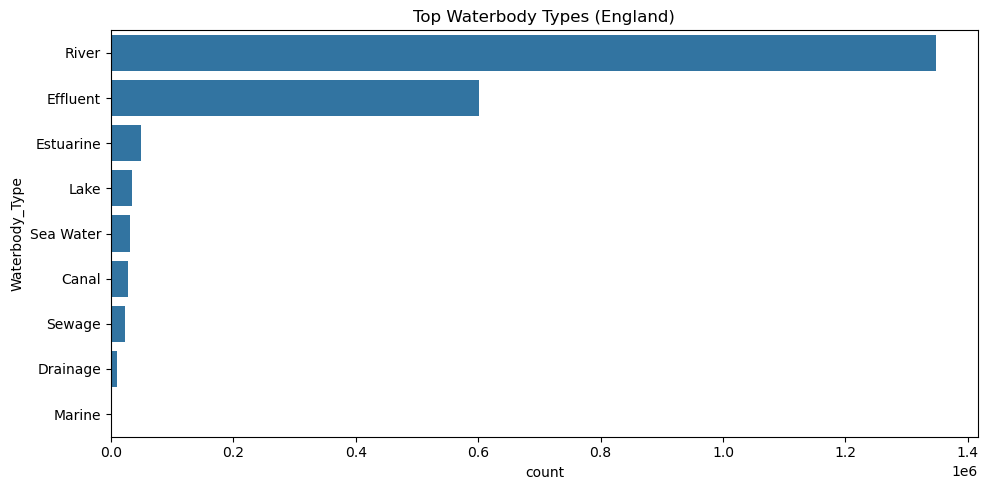


--- WQI Categories ---
    CCME_WQI   count
0       Good  918367
1  Excellent  445370
2   Marginal  325577
3       Fair  313167
4       Poor  125371


In [5]:

print("--- Top Waterbody Types di England Data ---")
top_wb = df_eng.groupBy("Waterbody_Type").count().orderBy(F.desc("count")).limit(10).toPandas()
print(top_wb)

plt.figure(figsize=(10,5))
sns.barplot(data=top_wb, x='count', y='Waterbody_Type')
plt.title("Top Waterbody Types (England)")
plt.tight_layout()
plt.show()

print("\n--- WQI Categories ---")
wqi_counts = df_eng.groupBy("CCME_WQI").count().orderBy(F.desc("count")).toPandas()
print(wqi_counts)


## 5. Descriptive Statistic

In [6]:

print("--- Statistik WIMS Data ---")
df_wims = df_wims.withColumn("lat_float", F.col("samplingPoint_latitude").cast("float")).withColumn("lon_float", F.col("samplingPoint_longitude").cast("float"))
df_wims.select("result_clean", "lat_float", "lon_float").summary("count", "mean", "min", "max", "stddev").show()

print("--- Statistik Dim Station ---")
df_dim.select("population_density").summary("count", "mean", "min", "max", "stddev").show()


--- Statistik WIMS Data ---
+-------+-----------------+------------------+------------------+
|summary|     result_clean|         lat_float|         lon_float|
+-------+-----------------+------------------+------------------+
|  count|         53760993|          60064779|          60064779|
|   mean|7006.252722446167| 52.49841311219235|-1.640789887911889|
|    min|           -504.0|           49.8896|            -6.354|
|    max|            1.0E7|           55.8069|            1.7629|
| stddev|152093.4993409803|1.3364606497508988|1.4741767078460195|
+-------+-----------------+------------------+------------------+

--- Statistik Dim Station ---
+-------+------------------+
|summary|population_density|
+-------+------------------+
|  count|                14|
|   mean| 1354.473268372672|
|    min|         19.085207|
|    max|         5937.4863|
| stddev|2134.0567177298262|
+-------+------------------+



## 6. Distribution Analysis / Outlier Detection

Distribusi pH pada England Data


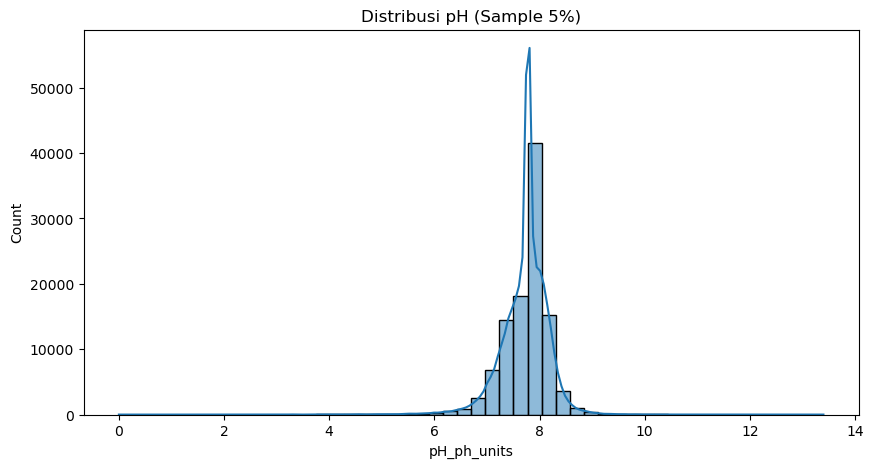

In [7]:

print("Distribusi pH pada England Data")
sample_ph = df_eng.select("pH_ph_units").sample(fraction=0.05, seed=42).toPandas()
sample_ph['pH_ph_units'] = sample_ph['pH_ph_units'].astype(float)

plt.figure(figsize=(10,5))
sns.histplot(sample_ph['pH_ph_units'].dropna(), bins=50, kde=True)
plt.title("Distribusi pH (Sample 5%)")
plt.show()


## 7. Relationship / Spatial Analysis

Melihat Spatial Distribution dari 14 Station di UK


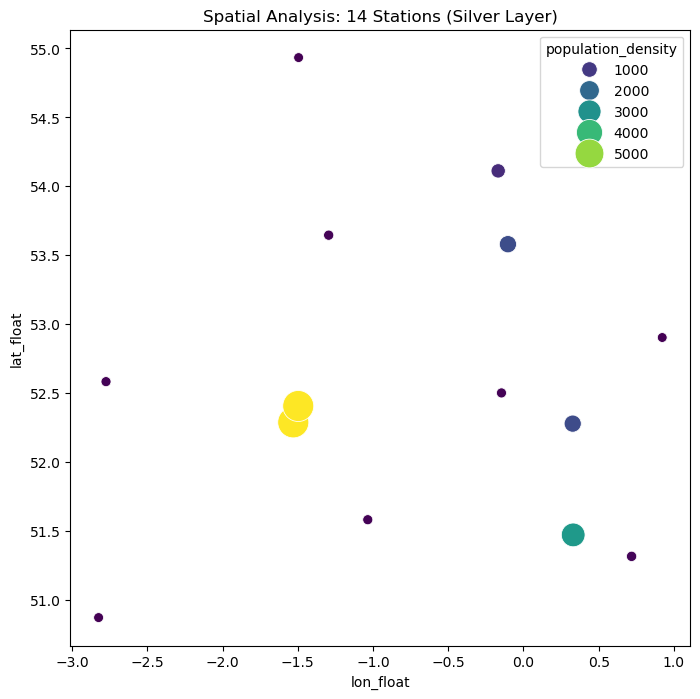

In [8]:

print("Melihat Spatial Distribution dari 14 Station di UK")
stations_pd = df_wims.select("samplingPoint_prefLabel", "lat_float", "lon_float").dropDuplicates(["samplingPoint_prefLabel"]).join(
    df_dim, df_wims["samplingPoint_prefLabel"] == df_dim["area_name"], "inner"
).toPandas()

plt.figure(figsize=(8,8))
sns.scatterplot(data=stations_pd, x='lon_float', y='lat_float', size='population_density', sizes=(50, 500), hue='population_density', palette='viridis')
plt.title("Spatial Analysis: 14 Stations (Silver Layer)")
plt.show()


## 8. Time-Based Analysis

Tren Pengambilan Sampel per Tahun di WIMS


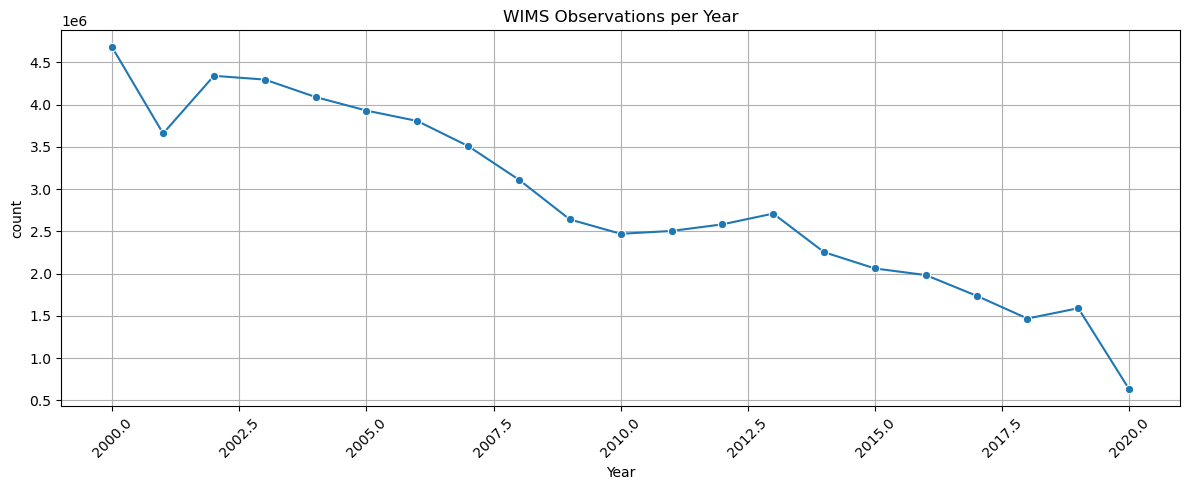

In [9]:

print("Tren Pengambilan Sampel per Tahun di WIMS")
# Ambil tahun dari phenomenonTime
df_wims_time = df_wims.withColumn("Year", F.substring("phenomenonTime", 1, 4))
yearly_counts = df_wims_time.groupBy("Year").count().orderBy("Year").toPandas()

# Hapus outlier tahun (jika ada error entry)
yearly_counts['Year'] = yearly_counts['Year'].astype(int)
yearly_counts = yearly_counts[(yearly_counts['Year'] >= 2000) & (yearly_counts['Year'] <= 2026)]

plt.figure(figsize=(12,5))
sns.lineplot(data=yearly_counts, x='Year', y='count', marker='o')
plt.title("WIMS Observations per Year")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## 9. Data Consistency Check

In [10]:

print("Verifikasi apakah ada pH > 14 atau < 0 (Harusnya 0 di Silver)")
invalid_ph = df_eng.withColumn("pH", F.col("pH_ph_units").cast("float")).filter((F.col("pH") < 0) | (F.col("pH") > 14)).count()
print(f"Invalid pH (England): {invalid_ph}")

invalid_temp_wims = df_wims.filter((F.col("determinand_notation") == '0076') & ((F.col("result_clean") < -10) | (F.col("result_clean") > 50))).count()
print(f"Invalid Temp (WIMS): {invalid_temp_wims}")


Verifikasi apakah ada pH > 14 atau < 0 (Harusnya 0 di Silver)
Invalid pH (England): 0
Invalid Temp (WIMS): 0


## 10. Business/Domain Validation

In [11]:

print("Memastikan Dimensi Stasiun sesuai Business Logic (UK Region, >0 Pop Density)")
valid_dims = df_dim.filter(F.col("population_density") >= 0).count()
print(f"Stasiun dengan populasi valid: {valid_dims} dari {df_dim.count()}")
print("Menutup Spark Session.")
spark.stop()


Memastikan Dimensi Stasiun sesuai Business Logic (UK Region, >0 Pop Density)
Stasiun dengan populasi valid: 14 dari 14
Menutup Spark Session.
